# Preliminary

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
# Read the CSV file
file_path = "EsophagealBank_DATA_2024-12-20_1341.csv"
df = pd.read_csv(file_path)
df

/tmp/ipykernel_349118/2311212610.py:3: DtypeWarning: Columns (0,4,83,91,113,149,215,235,238,251,252,253,279,282,285,288,292,295,296,297,298,300,301,303,313,323,326,328,340,342,343,345,349,354,356,369,378,390,392,394,396,405,413,414,421,425,426,429,432,435,438,441,444,447,450,459,460,461,462,480,481,482,484,487,492,499,502,506) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,id,redcap_event_name,redcap_repeat_instrument,redcap_repeat_instance,edmonton_symptom_assessment_system_esas_timestamp,esas_date,e_pain,e_fatigue,e_nausea,e_depression,...,other_distant_recurrence,dfs_2,current_status,cause_death,last_fu_date,overall_survival,dfs,dod,overall_survival_2,survival_data_complete
0,000Test,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000Test,preoperative_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000Test,1_month_postop_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-15.0,3.0,NaN,2019-05-03,32.0,-3.0,2019-05-15,44.0,0.0
3,000Test,5_years_postop_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3263.0,1.0,NaN,2020-11-09,588.0,3807.0,2019-05-15,44.0,2.0
4,000Test,baseline_arm_1,edmonton_symptom_assessment_system_esas,1.0,2019-05-13 10:09:32,NaN,1.0,1.0,8.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18744,1745,baseline_arm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18745,1745,baseline_arm_1,edmonton_symptom_assessment_system_esas,1.0,NaN,2024-12-16,7.0,8.0,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18746,1745,baseline_arm_1,functional_assessment_of_cancer_therapy_fact_e...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18747,1745,baseline_arm_1,presenting_symptoms,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Extract columns with "GE1" to "GE6" with the first and second columns (patient id, duration)
columns_to_extract = ["id", "redcap_event_name"] + [f"ge{i}" for i in range(1, 7)]
df_extracted = df[columns_to_extract]

# Display the extracted data
print(df_extracted)

            id     redcap_event_name  ge1  ge2  ge3  ge4  ge5  ge6
0      000Test        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN
1      000Test    preoperative_arm_1  NaN  NaN  NaN  NaN  NaN  NaN
2      000Test  1_month_postop_arm_1  NaN  NaN  NaN  NaN  NaN  NaN
3      000Test  5_years_postop_arm_1  NaN  NaN  NaN  NaN  NaN  NaN
4      000Test        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN
...        ...                   ...  ...  ...  ...  ...  ...  ...
18744     1745        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN
18745     1745        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN
18746     1745        baseline_arm_1  1.0  1.0  2.0  1.0  2.0  1.0
18747     1745        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN
18748     1745        baseline_arm_1  NaN  NaN  NaN  NaN  NaN  NaN

[18749 rows x 8 columns]


In [5]:
# Define GE score columns
ge_cols = ["ge1", "ge2", "ge3", "ge4", "ge5", "ge6"]

# Remove rows where all GE scores are NaN
df_filtered = df_extracted.dropna(subset=ge_cols, how="all")

# Group by 'id' and get unique redcap_event_name values per id
ids_with_both = df_filtered.groupby("id")["redcap_event_name"].unique()

# Filter for IDs that contain both 'baseline_arm_1' and 'preoperative_arm_1'
ids_with_both = ids_with_both[ids_with_both.apply(lambda x: {"baseline_arm_1", "preoperative_arm_1"}.issubset(set(x)))]

# Count the number of unique patients that satisfy the condition
num_ids_with_both = len(ids_with_both)

print(f"Number of IDs with both Baseline and Preoperative (after removing NaN GE scores): {num_ids_with_both}")

Number of IDs with both Baseline and Preoperative (after removing NaN GE scores): 271


In [6]:
# Count the number of rows for each patient (id)
patient_row_counts = df["id"].value_counts()

# Display the result
print(patient_row_counts)

id
826     38
629     37
536     36
557     33
1205    32
        ..
1432     1
1355     1
1677     1
1672     1
1676     1
Name: count, Length: 1732, dtype: int64


In [7]:
# Get unique categories in "redcap_event_name"
unique_categories = df["redcap_event_name"].unique()

# Display the result
print(unique_categories)

['baseline_arm_1' 'preoperative_arm_1' '1_month_postop_arm_1'
 '5_years_postop_arm_1' 'surgery_arm_1' '1_year_postop_arm_1'
 '3_months_postop_arm_1' '6_months_postop_arm_1' '2_years_postop_arm_1'
 '3_years_postop_arm_1' '4_years_postop_arm_1']


In [8]:
# Create new columns for emotional well-being sub-domain scores
df["ge1_score"] = 4 - df["ge1"]
df["ge2_score"] = df["ge2"]
df["ge3_score"] = 4 - df["ge3"]
df["ge4_score"] = 4 - df["ge4"]
df["ge5_score"] = 4 - df["ge5"]
df["ge6_score"] = 4 - df["ge6"]

# Filter data for baseline_arm_1 and preoperative_arm_1
baseline_df = df[df["redcap_event_name"] == "baseline_arm_1"]
preoperative_df = df[df["redcap_event_name"] == "preoperative_arm_1"]

# distribution of FACT-E Emotional Well-Being sub-domain at 1) baseline and 2) pre-operative.

In [9]:
# Calculate distribution (value counts, ignoring missing values)
baseline_distribution = baseline_df[["ge1_score", "ge2_score", "ge3_score", "ge4_score", "ge5_score", "ge6_score"]].apply(pd.Series.value_counts)
preoperative_distribution = preoperative_df[["ge1_score", "ge2_score", "ge3_score", "ge4_score", "ge5_score", "ge6_score"]].apply(pd.Series.value_counts)

# Display results - Table 
print("Baseline Distribution:")
print(baseline_distribution)

print("\nPreoperative Distribution:")
print(preoperative_distribution)

Baseline Distribution:
     ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  ge6_score
0.0         57         99         31        126         95        170
1.0        106        128         44        145         99        171
2.0        226        305        100        222        154        238
3.0        282        281        156        249        241        236
4.0        316        145        588        231        382        160

Preoperative Distribution:
     ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  ge6_score
0.0          7         31         14         23         16         37
1.0         23         35         16         44         36         57
2.0         79        119         37         93         53         94
3.0        120        127         62        128        119        125
4.0        178         93        273        119        181         92


In [10]:
# Melt the data for visualization
baseline_melted = baseline_df.melt(id_vars=["id"], value_vars=["ge1_score", "ge2_score", "ge3_score", "ge4_score", "ge5_score", "ge6_score"], var_name="Score Type", value_name="Score")
preoperative_melted = preoperative_df.melt(id_vars=["id"], value_vars=["ge1_score", "ge2_score", "ge3_score", "ge4_score", "ge5_score", "ge6_score"], var_name="Score Type", value_name="Score")

In [11]:
baseline_melted["Timepoint"] = "Baseline"
preoperative_melted["Timepoint"] = "Preoperative"

combined_df = pd.concat([baseline_melted, preoperative_melted])
combined_df

,id,Score Type,Score,Timepoint
0,000Test,ge1_score,NaN,Baseline
1,000Test,ge1_score,NaN,Baseline
2,000Test,ge1_score,NaN,Baseline
3,000Test,ge1_score,NaN,Baseline
4,000Test,ge1_score,NaN,Baseline
...,...,...,...,...
14359,1734,ge6_score,NaN,Preoperative
14360,1740,ge6_score,NaN,Preoperative
14361,1740,ge6_score,NaN,Preoperative
14362,1740,ge6_score,2.0,Preoperative


In [12]:
# Ensure no duplicate issues
combined_df = combined_df.dropna()

combined_df

,id,Score Type,Score,Timepoint
14,2,ge1_score,3.0,Baseline
18,3,ge1_score,2.0,Baseline
23,4,ge1_score,4.0,Baseline
36,7,ge1_score,1.0,Baseline
41,8,ge1_score,4.0,Baseline
...,...,...,...,...
14328,1710,ge6_score,2.0,Preoperative
14336,1715,ge6_score,2.0,Preoperative
14346,1723,ge6_score,3.0,Preoperative
14353,1726,ge6_score,4.0,Preoperative


In [13]:
score_distribution_by_timepoint = combined_df.groupby(["Score", "Timepoint"]).size().unstack()
print(score_distribution_by_timepoint)

Timepoint  Baseline  Preoperative
Score                            
0.0             578           128
1.0             693           211
2.0            1245           475
3.0            1445           681
4.0            1822           936


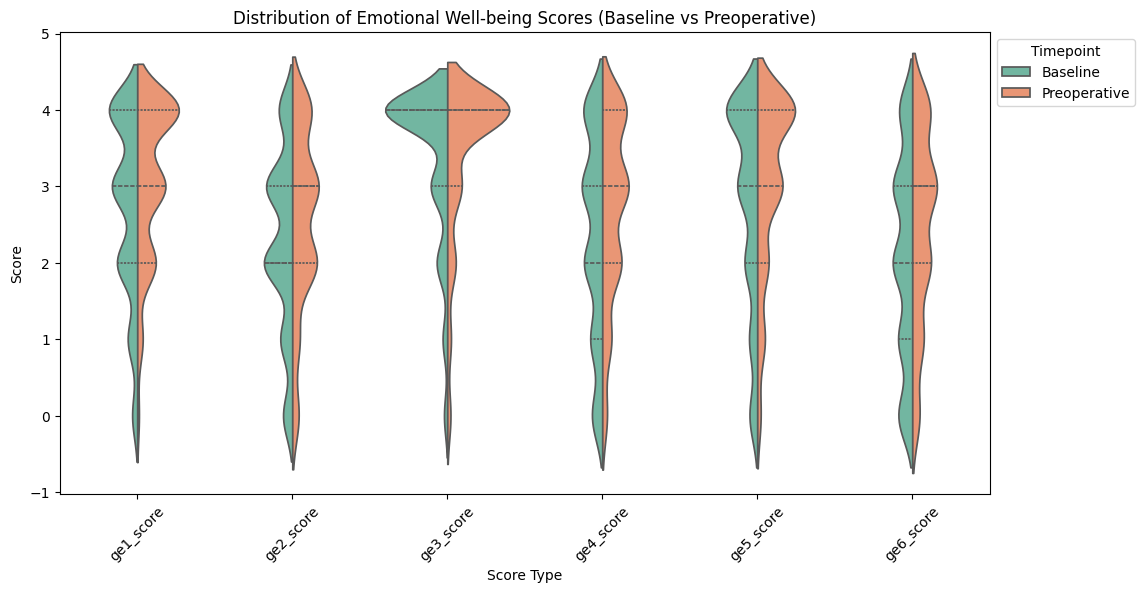

In [14]:
# === Violin Plot ===
plt.figure(figsize=(12, 6))
sns.violinplot(x="Score Type", y="Score", hue="Timepoint", data=combined_df, split=True, inner="quartile", palette="Set2")
plt.title("Distribution of Emotional Well-being Scores (Baseline vs Preoperative)")
plt.xticks(rotation=45)
plt.legend(title="Timepoint", loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

# frequency of those that have both baseline and pre-operative FACT-E

In [15]:
# Identify patients who have both baseline and preoperative
patients_with_both = combined_df.groupby("id")["Timepoint"].unique()
patients_with_both = patients_with_both[patients_with_both.apply(lambda x: {"Baseline", "Preoperative"}.issubset(set(x)))].index

# Keep only rows where id is in the list of patients_with_both
filtered_df = combined_df[combined_df["id"].isin(patients_with_both)]

print(filtered_df)

score_distribution_by_timepoint2 = filtered_df.groupby(["Score", "Timepoint"]).size().unstack()
print(score_distribution_by_timepoint2)

         id Score Type  Score     Timepoint
233      55  ge1_score    2.0      Baseline
323      78  ge1_score    4.0      Baseline
482     125  ge1_score    3.0      Baseline
489     127  ge1_score    1.0      Baseline
496     128  ge1_score    4.0      Baseline
...     ...        ...    ...           ...
14324  1708  ge6_score    2.0  Preoperative
14328  1710  ge6_score    2.0  Preoperative
14336  1715  ge6_score    2.0  Preoperative
14346  1723  ge6_score    3.0  Preoperative
14353  1726  ge6_score    4.0  Preoperative

[3606 rows x 4 columns]
Timepoint  Baseline  Preoperative
Score                            
0.0             170            86
1.0             252           152
2.0             420           343
3.0             467           500
4.0             538           678


In [16]:
#Some patients can have more than one redcap_event - i.e. patient id 619
filtered_df[filtered_df['id']== 619]

,id,Score Type,Score,Timepoint
2524,619,ge1_score,2.0,Baseline
2525,619,ge1_score,4.0,Baseline
9736,619,ge2_score,2.0,Baseline
9737,619,ge2_score,2.0,Baseline
16948,619,ge3_score,3.0,Baseline
16949,619,ge3_score,3.0,Baseline
24160,619,ge4_score,1.0,Baseline
24161,619,ge4_score,3.0,Baseline
31372,619,ge5_score,1.0,Baseline
31373,619,ge5_score,3.0,Baseline


In [17]:
# Count the number of unique patients
num_patients_with_both = len(patients_with_both)

print(f"Number of patients with both Baseline and Preoperative: {num_patients_with_both}")

Number of patients with both Baseline and Preoperative: 271


In [18]:
ge_scores = ["ge1_score", "ge2_score", "ge3_score", "ge4_score", "ge5_score", "ge6_score"]

# Separate data by Timepoint
baseline_df_filtered = filtered_df[filtered_df["Timepoint"] == "Baseline"]
preoperative_df_filtered = filtered_df[filtered_df["Timepoint"] == "Preoperative"]

# Pivot table: Count occurrences of each Score for each Score Type
baseline_table = baseline_df_filtered.pivot_table(index="Score", columns="Score Type", aggfunc="size", fill_value=0)
preoperative_table = preoperative_df_filtered.pivot_table(index="Score", columns="Score Type", aggfunc="size", fill_value=0)

# Display the tables
print("Baseline Score Distribution Table:")
print(baseline_table)

print("\nPreoperative Score Distribution Table:")
print(preoperative_table)


Baseline Score Distribution Table:
Score Type  ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  ge6_score
Score                                                                       
0.0                15         29          7         33         30         56
1.0                33         45         17         58         34         65
2.0                82        112         30         69         54         73
3.0                94         71         52         87         89         74
4.0                88         51        191         63        102         43

Preoperative Score Distribution Table:
Score Type  ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  ge6_score
Score                                                                       
0.0                 5         24         10         15         10         22
1.0                15         26         12         31         24         44
2.0                56         87         28         63         41         68
3

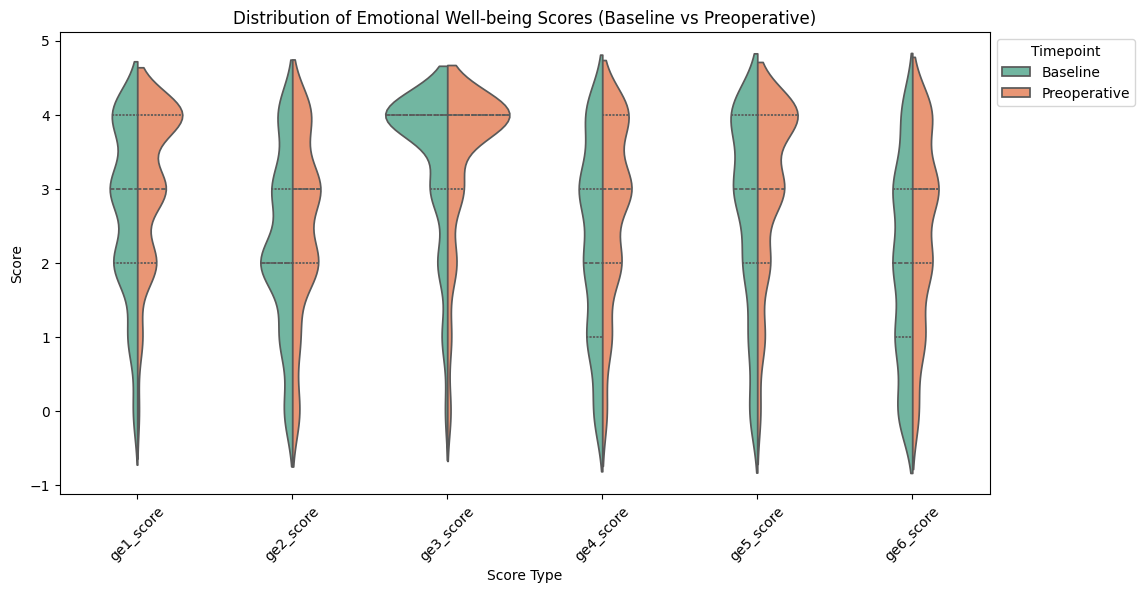

In [19]:
# === Violin Plot ===
plt.figure(figsize=(12, 6))
sns.violinplot(x="Score Type", y="Score", hue="Timepoint", data=filtered_df, split=True, inner="quartile", palette="Set2")
plt.title("Distribution of Emotional Well-being Scores (Baseline vs Preoperative)")
plt.xticks(rotation=45)
plt.legend(title="Timepoint", loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

# calculate how many improve, stay the same, or decrease from baseline --> preop

In [20]:
filtered_df

,id,Score Type,Score,Timepoint
233,55,ge1_score,2.0,Baseline
323,78,ge1_score,4.0,Baseline
482,125,ge1_score,3.0,Baseline
489,127,ge1_score,1.0,Baseline
496,128,ge1_score,4.0,Baseline
...,...,...,...,...
14324,1708,ge6_score,2.0,Preoperative
14328,1710,ge6_score,2.0,Preoperative
14336,1715,ge6_score,2.0,Preoperative
14346,1723,ge6_score,3.0,Preoperative


In [21]:
# Average scores for duplicated (id, Score Type, Timepoint) entries
filtered_df_dup_avged = filtered_df.groupby(["id", "Score Type", "Timepoint"], as_index=False)["Score"].mean()
filtered_df_dup_avged

,id,Score Type,Timepoint,Score
0,228,ge1_score,Baseline,4.0
1,228,ge1_score,Preoperative,2.0
2,228,ge2_score,Baseline,0.0
3,228,ge2_score,Preoperative,1.0
4,228,ge3_score,Baseline,4.0
...,...,...,...,...
3217,78,ge4_score,Preoperative,3.0
3218,78,ge5_score,Baseline,4.0
3219,78,ge5_score,Preoperative,4.0
3220,78,ge6_score,Baseline,1.0


In [22]:
# Count expected number of rows per patient (should be 12 per patient)
expected_rows_per_patient = 12

# Count actual rows per patient
patient_counts = filtered_df_dup_avged.groupby("id").size()
patient_counts
# Identify patients who do NOT have exactly 12 rows
patients_missing_rows = patient_counts[patient_counts != expected_rows_per_patient]

# Display IDs and their actual row count
print("Patients with missing rows and their row count:")
print(patients_missing_rows)

Patients with missing rows and their row count:
id
260     11
548     10
566     11
788     11
826     11
898     11
1003    11
1012    11
1043    11
1106    11
1126     9
1313    11
1409    10
1551    11
1560    11
1629    11
1710     9
1715    11
1723     6
dtype: int64


In [23]:
# Pivot to make Score Types as columns and fill missing values with 0
pivot_df = filtered_df_dup_avged.pivot_table(index=["id", "Timepoint"], 
                                   columns="Score Type", 
                                   values="Score", 
                                   fill_value=0)

# Sum across all Score Types for each (id, Timepoint)
pivot_df["Total Score"] = pivot_df.sum(axis=1)

# Reset index to bring back "id" and "Timepoint" as columns
pivot_df = pivot_df.reset_index()
print(pivot_df)



# Count the number of non-missing values for each row (before replacing NaNs with 0)
num_answered = filtered_df_dup_avged.pivot_table(index=["id", "Timepoint"], 
                                       columns="Score Type", 
                                       values="Score", 
                                       aggfunc=lambda x: x.notna().sum())
num_answered

Score Type   id     Timepoint  ge1_score  ge2_score  ge3_score  ge4_score  \
0           228      Baseline        4.0        0.0        4.0        4.0   
1           228  Preoperative        2.0        1.0        4.0        3.0   
2           260      Baseline        4.0        2.0        0.0        2.0   
3           260  Preoperative        3.0        3.0        4.0        3.0   
4           364      Baseline        4.0        2.0        4.0        0.0   
..          ...           ...        ...        ...        ...        ...   
537         166  Preoperative        4.0        4.0        4.0        4.0   
538          55      Baseline        2.0        2.0        3.0        1.0   
539          55  Preoperative        2.0        2.0        3.0        4.0   
540          78      Baseline        4.0        2.0        4.0        2.0   
541          78  Preoperative        4.0        2.0        4.0        3.0   

Score Type  ge5_score  ge6_score  Total Score  
0                 4.0      

Score Type        ge1_score  ge2_score  ge3_score  ge4_score  ge5_score  \
id  Timepoint                                                             
228 Baseline            1.0        1.0        1.0        1.0        1.0   
    Preoperative        1.0        1.0        1.0        1.0        1.0   
260 Baseline            1.0        1.0        NaN        1.0        1.0   
    Preoperative        1.0        1.0        1.0        1.0        1.0   
364 Baseline            1.0        1.0        1.0        1.0        1.0   
...                     ...        ...        ...        ...        ...   
166 Preoperative        1.0        1.0        1.0        1.0        1.0   
55  Baseline            1.0        1.0        1.0        1.0        1.0   
    Preoperative        1.0        1.0        1.0        1.0        1.0   
78  Baseline            1.0        1.0        1.0        1.0        1.0   
    Preoperative        1.0        1.0        1.0        1.0        1.0   

Score Type        ge6_score  
id  Timepoint                
228 Baseline            1.0  
    Preoperative        1.0  
260 Baseline            1.0  
    Preoperative        1.0  
364 Baseline            1.0  
...                     ...  
166 Preoperative        1.0  
55  Baseline            1.0  
    Preoperative        1.0  
78  Baseline            1.0  
    Preoperative        1.0  

[542 rows x 6 columns]

In [24]:
#show the table where it is missing
num_answered[num_answered.sum(axis=1) != 6]

,Score Type,ge1_score,ge2_score,ge3_score,ge4_score,ge5_score,ge6_score
id,Timepoint,,,,,,
260,Baseline,1.0,1.0,NaN,1.0,1.0,1.0
548,Baseline,1.0,1.0,NaN,1.0,NaN,1.0
566,Baseline,1.0,1.0,NaN,1.0,1.0,1.0
788,Preoperative,1.0,1.0,NaN,1.0,1.0,1.0
826,Preoperative,1.0,1.0,1.0,1.0,1.0,NaN
898,Baseline,1.0,1.0,NaN,1.0,1.0,1.0
1003,Baseline,1.0,1.0,1.0,NaN,1.0,1.0
1012,Baseline,1.0,1.0,1.0,NaN,1.0,1.0
1043,Baseline,1.0,1.0,NaN,1.0,1.0,1.0


In [25]:
# Ensure num_answered has the same index as pivot_df
num_answered_sum = num_answered.sum(axis=1).reindex(pivot_df.set_index(["id", "Timepoint"]).index)

# Compute the Adjusted Score safely
pivot_df["EWB subscale Score"] = (pivot_df["Total Score"] * 6) / num_answered_sum.values


# Display result
pivot_df

Score Type,id,Timepoint,ge1_score,ge2_score,ge3_score,ge4_score,ge5_score,ge6_score,Total Score,EWB subscale Score
0,228,Baseline,4.0,0.0,4.0,4.0,4.0,4.0,20.0,20.0
1,228,Preoperative,2.0,1.0,4.0,3.0,4.0,3.0,17.0,17.0
2,260,Baseline,4.0,2.0,0.0,2.0,3.0,4.0,15.0,18.0
3,260,Preoperative,3.0,3.0,4.0,3.0,4.0,4.0,21.0,21.0
4,364,Baseline,4.0,2.0,4.0,0.0,2.0,1.0,13.0,13.0
...,...,...,...,...,...,...,...,...,...,...
537,166,Preoperative,4.0,4.0,4.0,4.0,4.0,4.0,24.0,24.0
538,55,Baseline,2.0,2.0,3.0,1.0,0.0,0.0,8.0,8.0
539,55,Preoperative,2.0,2.0,3.0,4.0,2.0,1.0,14.0,14.0
540,78,Baseline,4.0,2.0,4.0,2.0,4.0,1.0,17.0,17.0


In [26]:
# Pivot to get baseline and preoperative scores side by side
score_comparison = pivot_df.pivot(index="id", columns="Timepoint", values="EWB subscale Score")

# Compute the change: preoperative - baseline
score_comparison["Change"] = score_comparison["Preoperative"] - score_comparison["Baseline"]

# Categorize improvement, no change, or decline
score_comparison["Trend"] = score_comparison["Change"].apply(
    lambda x: "Improved" if x > 0 else "Same" if x == 0 else "Decreased"
)

# Display result
print(score_comparison[["Baseline", "Preoperative", "Change", "Trend"]])


Timepoint  Baseline  Preoperative  Change      Trend
id                                                  
228            20.0          17.0    -3.0  Decreased
260            18.0          21.0     3.0   Improved
364            13.0          22.0     9.0   Improved
455             6.0          12.0     6.0   Improved
461             6.0          19.0    13.0   Improved
..              ...           ...     ...        ...
160            21.0          20.0    -1.0  Decreased
161            24.0          15.0    -9.0  Decreased
166            21.0          24.0     3.0   Improved
55              8.0          14.0     6.0   Improved
78             17.0          20.0     3.0   Improved

[271 rows x 4 columns]


/tmp/ipykernel_349118/3921134547.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trend_counts.index, y=trend_counts.values, palette=["green", "gray", "red"])


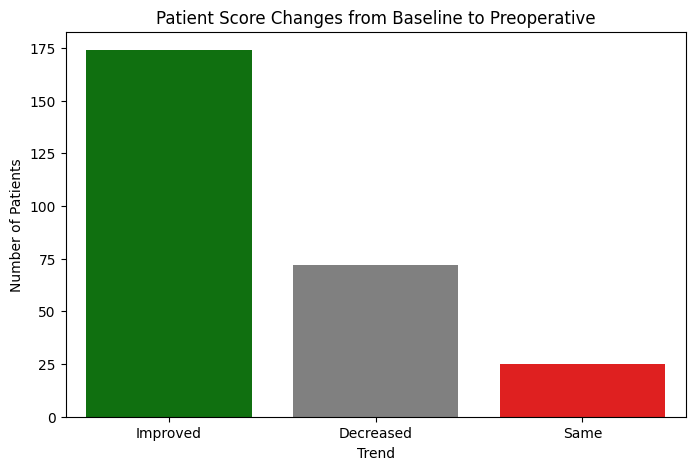

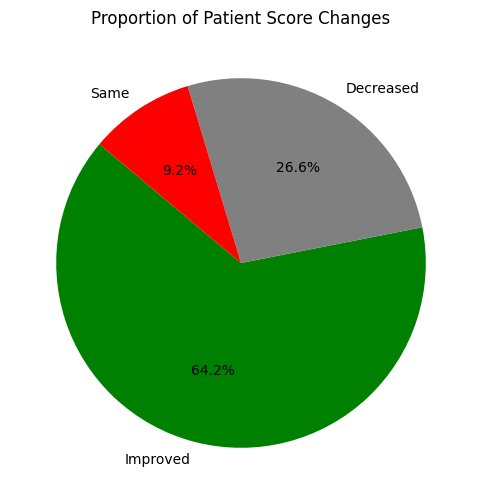

In [27]:
# Count the number of patients in each category
trend_counts = score_comparison["Trend"].value_counts()

# === 1. Bar Plot ===
plt.figure(figsize=(8, 5))
sns.barplot(x=trend_counts.index, y=trend_counts.values, palette=["green", "gray", "red"])
plt.title("Patient Score Changes from Baseline to Preoperative")
plt.xlabel("Trend")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

# === 2. Pie Chart ===
plt.figure(figsize=(6, 6))
plt.pie(trend_counts, labels=trend_counts.index, autopct="%1.1f%%", colors=["green", "gray", "red"], startangle=140)
plt.title("Proportion of Patient Score Changes")
plt.show()


# Categorize patients into: 1) improvers or 2) decliners / stay the same

In [28]:
score_comparison

Timepoint,Baseline,Preoperative,Change,Trend
id,,,,
228,20.0,17.0,-3.0,Decreased
260,18.0,21.0,3.0,Improved
364,13.0,22.0,9.0,Improved
455,6.0,12.0,6.0,Improved
461,6.0,19.0,13.0,Improved
...,...,...,...,...
160,21.0,20.0,-1.0,Decreased
161,24.0,15.0,-9.0,Decreased
166,21.0,24.0,3.0,Improved


In [30]:
# Re-categorize into two groups
score_comparison["Trend Category"] = score_comparison["Change"].apply(lambda x: "Improved" if x > 0 else "Decreased/Same")

score_comparison

Timepoint,Baseline,Preoperative,Change,Trend,Trend Category
id,,,,,
228,20.0,17.0,-3.0,Decreased,Decreased/Same
260,18.0,21.0,3.0,Improved,Improved
364,13.0,22.0,9.0,Improved,Improved
455,6.0,12.0,6.0,Improved,Improved
461,6.0,19.0,13.0,Improved,Improved
...,...,...,...,...,...
160,21.0,20.0,-1.0,Decreased,Decreased/Same
161,24.0,15.0,-9.0,Decreased,Decreased/Same
166,21.0,24.0,3.0,Improved,Improved


# statistically significantly associated with 1) occurrence of adverse events

# statistically significantly associated with 2) hospital length of stay

# statistically significantly associated with 3) 30-day hospital readmission rate